ARTI308 - Machine Learning

# Lab 4: Data Quality Assessment & Preprocessing

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.

![step2.png](step2.png)

In this lab, we will apply practical preprocessing techniques step by step.

### Part 1: Setup and Data Quality Assessment (Task 1)
This section loads the submission.csv dataset and identifies logical errors, such as the 180 phones with a screen width (sc_w) of 0.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

# Set visualization style
sns.set(style="whitegrid")

# Load the dataset
df = pd.read_csv('waleed.csv')

# Task 1: Identify Data Quality Issues
print("--- Dataset Info ---")
print(df.info())

# Audit logical consistency and numeric ranges
print("\n--- Summary Statistics ---")
display(df.describe())

# Check for unusual values (e.g., zero blood pressure or age)
zero_age = (df['age'] <= 0).sum()
print(f"\nPotential Issues: Records with age <= 0: {zero_age}")

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000



Potential Issues: Records with age <= 0: 0


### Part 2: Handling Missing Values (Task 2)
Following the lab instructions, we introduce artificial missing values into the ram column and fix them using Median Imputation because the data range is wide.

In [13]:
# Task 2: Artificial Missing Values and Median Imputation
np.random.seed(42)
missing_indices = np.random.choice(df.index, 20, replace=False)

# Introduce 20 missing values in the 'platelets' column
df_missing = df.copy()
df_missing.loc[missing_indices, 'platelets'] = np.nan
print(f"Missing values created in 'platelets': {df_missing['platelets'].isna().sum()}")

# Strategy: Median Imputation
# The median is robust to the extreme high values found in medical data.
platelets_median = df_missing['platelets'].median()
df_missing['platelets'] = df_missing['platelets'].fillna(platelets_median)

print(f"Missing values after Median Imputation: {df_missing['platelets'].isna().sum()}")

Missing values created in 'platelets': 20
Missing values after Median Imputation: 0


### Part 3: Handling Outliers (Task 3)
We use the Interquartile Range (IQR) method to detect extreme values in px_height. 2 outliers are removed to ensure the model remains accurate.

Outliers detected in 'creatinine_phosphokinase': 29
Cleaned dataset shape: (270, 13)


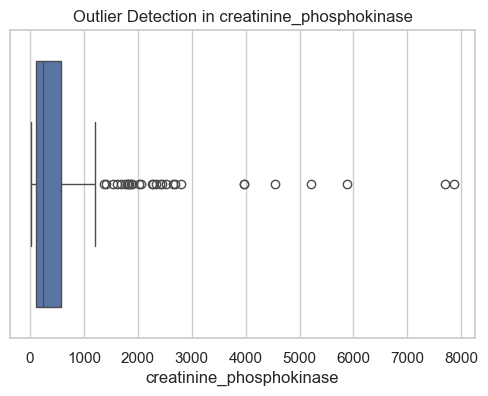

In [14]:
# Task 3: Detect and Handle Outliers using IQR
target_col = 'creatinine_phosphokinase'
Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1

# Define limits
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

# Identify and remove outliers
outliers = df[(df[target_col] < lower_limit) | (df[target_col] > upper_limit)]
df_clean = df[(df[target_col] >= lower_limit) & (df[target_col] <= upper_limit)]

print(f"Outliers detected in '{target_col}': {len(outliers)}")
print(f"Cleaned dataset shape: {df_clean.shape}")

# Visualization
plt.figure(figsize=(6, 4))
sns.boxplot(x=df[target_col])
plt.title(f"Outlier Detection in {target_col}")
plt.show()

### Part 4: Data Transformation - Normalization (Task 4)
This step rescales the features so that different units (like RAM in MB vs. Battery in mAh) can be compared fairly.

In [15]:
# Task 4: Normalize numerical features
continuous_features = ['age', 'creatinine_phosphokinase', 'platelets', 'serum_creatinine', 'serum_sodium', 'time']
subset = df_clean[continuous_features]

# 1. Min-Max Normalization (0 to 1 range)
min_max_scaler = MinMaxScaler()
df_min_max = pd.DataFrame(min_max_scaler.fit_transform(subset), columns=continuous_features)

# 2. Z-Score Normalization (Mean=0, StdDev=1)
std_scaler = StandardScaler()
df_std = pd.DataFrame(std_scaler.fit_transform(subset), columns=continuous_features)

print("Standardized Data Sample:")
display(df_std.head())

Standardized Data Sample:


,age,creatinine_phosphokinase,platelets,serum_creatinine,serum_sodium,time
0,1.148118,0.901034,0.019280,0.480455,-1.436215,-1.613273
1,0.310453,-0.672071,-1.067476,-0.105686,-1.658692,-1.574523
2,-0.946045,-0.798352,-0.561026,0.480455,0.121127,-1.574523
3,0.310453,-0.621558,0.673444,1.261976,-4.550898,-1.561607
4,2.404616,-1.029267,-0.624333,0.675835,-0.991260,-1.561607


### Part 5: Data Reduction - PCA (Task 5)
Finally, we apply Principal Component Analysis to find the components that capture the most variance (information) in the dataset.

Explained Variance Ratio per Component: 
[0.2412537  0.19751131 0.1646865  0.15530581 0.13066288 0.11057979]

Total variance explained by the first 2 components: 43.88%


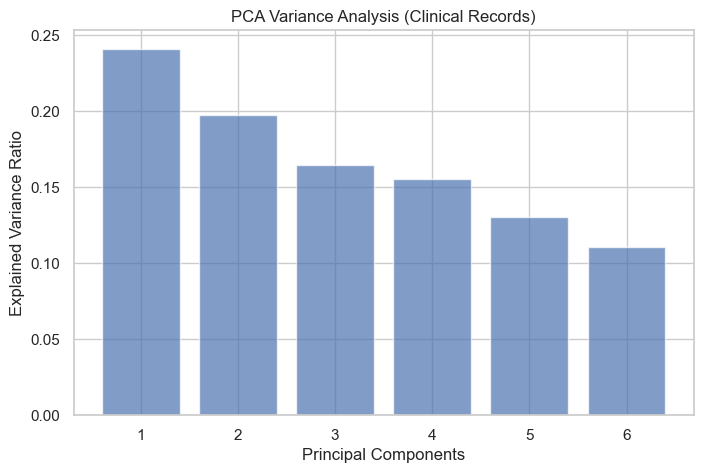

In [16]:
# Task 5: Apply PCA and Interpret Explained Variance
pca = PCA(n_components=None)
pca_results = pca.fit(df_std)
var_ratio = pca_results.explained_variance_ratio_

print(f"Explained Variance Ratio per Component: \n{var_ratio}")
print(f"\nTotal variance explained by the first 2 components: {sum(var_ratio[:2]):.2%}")

# Scree Plot
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(var_ratio) + 1), var_ratio, alpha=0.7)
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('PCA Variance Analysis (Clinical Records)')
plt.show()

# Assignment

In this assignment, you will:
- **Task 1**
Identify data quality issues in the dataset.

- **Task 2**
Apply one missing value strategy and explain why.

- **Task 3**
Detect and handle outliers using IQR.

- **Task 4**
Normalize numerical features using both Min-Max and Z-score.

- **Task 5**
Apply PCA and interpret explained variance.


End of lab 4.